# PRISM IBD Metabolomics Analysis
## MSc Health Data Science — Thesis Project
## Student: Mehvish
## Supervisor: Dr. Imane Guellil
## University of Birmingham

## Objective:
To classify IBD subtypes (Crohn's Disease, Ulcerative Colitis, and Healthy Controls)
using untargeted metabolomics data from the PRISM dataset (ST001000)
by comparing Random Forest and XGBoost machine learning models.

## Dataset:
- Source: Metabolomics Workbench, Study ID: ST001000
- Patients: 219
- Features: 8,000+ metabolites (we work with 20 selected features)
- Classes: CD (87), UC (76), Control (56)

## Step 1: Load the Data
We begin by importing the libraries we need.
- pandas: for loading and manipulating data tables
- numpy: for numerical operations
- matplotlib and seaborn: for visualisation later

In [2]:
# We import all the libraries we will need throughout this analysis
# It is good practice to import everything at the start
# so anyone reading the notebook can see all dependencies upfront

# pandas is used for loading and working with data tables (dataframes)
import pandas as pd

# numpy is used for numerical operations like random seed and array handling
import numpy as np

# matplotlib and seaborn are used for creating visualisations and plots
import matplotlib.pyplot as plt
import seaborn as sns

# We set a random seed at the start
# This ensures our results are reproducible every time we run the notebook
# 42 is a commonly used seed in research
np.random.seed(123)

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load and Inspect the PRISM Dataset
The PRISM dataset is in mwTab format — a standard format for metabolomics data.
The first 336 lines contain metadata (study information, patient details, sample info).
The actual metabolite measurements begin at line 337.
We first inspect the file structure to confirm this.

In [3]:
# The PRISM dataset is in mwTab format
# This format has a lot of metadata at the top before the real data begins
# We need to find exactly where the data starts
# In mwTab format, data begins after the line 'MS_METABOLITE_DATA_START'

# We open the file and search for this keyword
with open('ST001000_AN001878.txt', 'r') as f:

    # enumerate gives us both the line number and line content
    for i, line in enumerate(f):

        # We search for the keyword that marks where data begins
        if 'MS_METABOLITE_DATA_START' in line:
            print(f"Metadata ends at line: {i}")
            print(f"Real data starts at line: {i+2}")
            print(f"Therefore we skip: {i+1} lines when loading")

Metadata ends at line: 336
Real data starts at line: 338
Therefore we skip: 337 lines when loading


## Step 3: Read the Data into a Dataframe
Now we know the data starts at line 338, we load it properly into pandas.
sep='\t' means the data is tab-separated.
header=0 means the first row after skipping is the column names.

In [4]:
# Now we load the actual data into a pandas dataframe
# We skip the first 337 lines (336 metadata + 1 keyword line)
# sep='\t' means columns are separated by tabs not commas
# header=0 means the first row after skipping becomes our column names

df = pd.read_csv('ST001000_AN001878.txt',
                skiprows=337,   # skip all metadata lines
                sep='\t',       # tab separated file
                header=0)       # first row = column names

# Print the shape to confirm it loaded correctly
# shape = (rows, columns)
print("Shape of raw dataset (rows, columns):", df.shape)

# Show first 3 rows to see what it looks like
print("\nFirst 3 rows:")
df.head(3)

Shape of raw dataset (rows, columns): (219, 221)

First 3 rows:


,Samples,7122,7147,7150,7153,7184,7238,7406,7408,7421,...,UMCGIBD00588,UMCGIBD00106,UMCGIBD00393,UMCGIBD00458,UMCGIBD00254,UMCGIBD00593,UMCGIBD00233,UMCGIBD00238,UMCGIBD00027,UMCGIBD00064
0,Factors,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,...,Diagnosis:UC,Diagnosis:CD,Diagnosis:UC,Diagnosis:CD,Diagnosis:CD,Diagnosis:UC,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD,Diagnosis:CD
1,1-methylguanine,17.1701,0.0277991,0.0204992,0,63.307,12.718,288.785,0,21.2633,...,18.5965,92.0039,21.073,0,120.4,208.771,19.0111,119.421,246.494,71.9812
2,1-methylnicotinamide,454.239,103.944,0,0,6.17649,10.087,35.0669,152.784,241.846,...,0,135.398,632.785,33.3766,20.5003,63.4658,0,0,88.2876,267.929


## Step 4: Transpose the Dataframe
We flip rows and columns so that:
- Rows = patients (samples)
- Columns = metabolites (features)
This is the standard format required for machine learning.

In [5]:
# We transpose the dataframe using .T
# Transpose means flipping rows and columns
# Before: rows=metabolites, columns=patients
# After: rows=patients, columns=metabolites

df_transposed = df.T

# After transposing, the first row contains metabolite names
# We set this row as our column headers
df_transposed.columns = df_transposed.iloc[0]

# Now drop that first row since it became our column headers
df_transposed = df_transposed.drop(df_transposed.index[0])

# Print new shape to confirm the flip worked
print("Shape after transposing (patients, metabolites):", df_transposed.shape)

Shape after transposing (patients, metabolites): (220, 219)


## Step 5: Separate Labels and Features, Clean the Data
We separate the diagnosis labels (y) from the metabolite measurements (X).
We also remove any file marker rows that are not real patients.

In [6]:
# The 'Factors' column contains our diagnosis labels
# This is what we want the ML model to predict (CD, UC, or Control)
# We call this our TARGET variable - represented as y

# First let us save the diagnosis labels separately
y = df_transposed['Factors']

# Remove the Factors column from the main dataframe
# We only want metabolite measurements in X (our features)
X = df_transposed.drop(columns=['Factors'])

# Remove any rows that are file markers not real patients
# METABOLITES_END and END are mwTab file format markers
X = X[~X.index.str.contains('END|METABOLITES', na=False)]
y = y[~y.index.str.contains('END|METABOLITES', na=False)]

# Print the disease group counts
print("Disease group counts:")
print(y.value_counts())

print("\nShape of features X (patients, metabolites):", X.shape)
print("Shape of labels y (patients):", y.shape)

Disease group counts:
Factors
Diagnosis:CD         88
Diagnosis:UC         76
Diagnosis:Control    56
Name: count, dtype: int64

Shape of features X (patients, metabolites): (220, 218)
Shape of labels y (patients): (220,)


In [7]:
# We got 220 patients but we expect 219
# Let us check which patient index looks unusual
# Real patient IDs are numbers like 7122 or strings like UMCGIBD00588
# Any unusual index is likely a file marker we missed

# Print all unique index values that don't look like real patient IDs
print("Checking for unusual row indices:")
for idx in X.index:
    # Real PRISM patient IDs start with numbers or 'UMCGIBD'
    if not str(idx).startswith(('7', '8', '9', 'U', '1', '2', '3', '4', '5', '6')):
        print(f"Unusual index found: '{idx}'")

print("\nTotal patients:", len(X))

Checking for unusual row indices:
Unusual index found: 'LLDeep_0001'
Unusual index found: 'LLDeep_0003'
Unusual index found: 'LLDeep_0010'
Unusual index found: 'LLDeep_0011'
Unusual index found: 'LLDeep_0012'
Unusual index found: 'LLDeep_0015'
Unusual index found: 'LLDeep_0018'
Unusual index found: 'LLDeep_0021'
Unusual index found: 'LLDeep_0022'
Unusual index found: 'LLDeep_0024'
Unusual index found: 'LLDeep_0026'
Unusual index found: 'LLDeep_0027'
Unusual index found: 'LLDeep_0028'
Unusual index found: 'LLDeep_0029'
Unusual index found: 'LLDeep_0030'
Unusual index found: 'LLDeep_0033'
Unusual index found: 'LLDeep_0034'
Unusual index found: 'LLDeep_0037'
Unusual index found: 'LLDeep_0039'
Unusual index found: 'LLDeep_0043'
Unusual index found: 'LLDeep_0047'
Unusual index found: 'LLDeep_0052'

Total patients: 220


In [8]:
# We confirm our dataset is clean and ready
# All 220 patients are real patients from two cohorts:
# 1. PRISM cohort - IDs starting with numbers or UMCGIBD
# 2. LLDeep validation cohort - IDs starting with LLDeep_
# Both cohorts have valid diagnosis labels so we keep all patients

print("Final dataset summary:")
print("Total patients:", len(X))
print("\nDisease group counts:")
print(y.value_counts())
print("\nShape of X (patients, metabolites):", X.shape)
print("\nWe are ready to proceed to data cleaning!")

Final dataset summary:
Total patients: 220

Disease group counts:
Factors
Diagnosis:CD         88
Diagnosis:UC         76
Diagnosis:Control    56
Name: count, dtype: int64

Shape of X (patients, metabolites): (220, 218)

We are ready to proceed to data cleaning!


## Step 6: Remove Duplicate Columns
The dataset contains 106 duplicate metabolite column names.
Duplicate columns cause errors in machine learning.
We keep only the first occurrence of each metabolite name.

In [9]:
# Before we can do any analysis we must remove duplicate column names
# Duplicate columns exist because in untargeted metabolomics
# the same metabolite can be detected multiple times
# under slightly different conditions or ionisation modes
# Having duplicates confuses the ML model so we keep only the first occurrence

# First let us check how many duplicates exist
duplicates = X.columns.duplicated().sum()
print("Number of duplicate columns found:", duplicates)

# Remove duplicates by keeping only the first occurrence of each column name
# ~ means NOT duplicated - so we keep columns that are NOT duplicates
X_clean = X.loc[:, ~X.columns.duplicated()]

# Confirm the new shape after removing duplicates
print("Shape before removing duplicates:", X.shape)
print("Shape after removing duplicates:", X_clean.shape)
print("Columns removed:", X.shape[1] - X_clean.shape[1])

# Remove any columns that are file markers not real metabolites
# #END and METABOLITES_START are mwTab file format markers
# they appeared as column names when we transposed the data
# we must remove them before selecting features

file_markers = ['#END', 'METABOLITES_START', 'METABOLITES_END']

# Remove these columns if they exist
X_clean = X_clean.drop(columns=[col for col in file_markers
                                  if col in X_clean.columns])

print("Shape after removing file markers:", X_clean.shape)


Number of duplicate columns found: 106
Shape before removing duplicates: (220, 218)
Shape after removing duplicates: (220, 112)
Columns removed: 106
Shape after removing file markers: (220, 109)


## Step 7: Select 20 Random Features
 asked us to work with 20 randomly selected features first.
This tests our pipeline on a manageable subset before scaling to all 112 features.
We use a fixed random seed (42) to ensure the same 20 features are selected every run.

In [10]:
# We randomly select 20 features from our 112 unique metabolites
# Dr Guellil asked us to work with 20 features first
# This is a common approach in ML - test pipeline on small subset first
# np.random.seed(42) was set at the beginning so this is reproducible

selected_features = np.random.choice(X_clean.columns,
                                     size=20,        # select 20 features
                                     replace=False)  # no repeats

# Create new dataframe with only these 20 features
X_20 = X_clean[selected_features]

# Print the selected features
print("20 randomly selected metabolite features:")
for i, feature in enumerate(selected_features):
    print(f"{i+1}. {feature}")

print("\nShape of 20 feature dataset:", X_20.shape)

20 randomly selected metabolite features:
1. proline betaine
2. pyridoxamine
3. pyroglutamic acid
4. carnitine
5. isoleucine
6. C18:1 carnitine
7. ADMA
8. Harman
9. C36:2 PC
10. 5-acetylamino-6-amino-3-methyluracil
11. 3-methylxanthine
12. 1-methylguanine
13. N-acetylspermidine
14. linoleoyl ethanolamide
15. 3-methylhistidine
16. kynurenic acid
17. serine
18. C16:1 LPC plasmalogen
19. caffeine
20. N-Acetylglutamic acid

Shape of 20 feature dataset: (220, 20)


## Step 8: KNN Imputation
We use KNN imputation to fill any missing values.
K=5 means we find the 5 most similar patients and use their
average values to fill missing data.
KNN is preferred over median imputation for small datasets
because it is more biologically meaningful.

In [11]:
# We import KNN imputer from sklearn
from sklearn.impute import KNNImputer

# First convert all values to numeric
# errors='coerce' replaces any non-numeric values with NaN
X_20_numeric = X_20.apply(pd.to_numeric, errors='coerce')

# Create KNN imputer with K=5
# K=5 means we find 5 most similar patients
# and use their average values to fill missing data
imputer = KNNImputer(n_neighbors=5)

# Apply imputation to our data
# fit_transform learns from the data and fills missing values
X_imputed = imputer.fit_transform(X_20_numeric)

# Convert back to dataframe with original column names
X_imputed = pd.DataFrame(X_imputed,
                         columns=X_20_numeric.columns,
                         index=X_20_numeric.index)

# Confirm no missing values remain
print("Missing values before imputation:", X_20_numeric.isnull().sum().sum())
print("Missing values after imputation:", X_imputed.isnull().sum().sum())
print("Shape after imputation:", X_imputed.shape)

Missing values before imputation: 0
Missing values after imputation: 0
Shape after imputation: (220, 20)


## Step 9: Log Transformation
Log transformation is applied BEFORE normalisation.
This is the standard order in metabolomics research.
Log transformation first compresses skewed values,
then normalisation scales them to mean=0 and std=1.
We use log(x+1) to avoid log(0) which is undefined.

In [16]:
# We apply log transformation before normalisation
# This is the correct order for metabolomics data
# log(x+1) is used to avoid log(0) which is mathematically undefined
# np.abs() handles any negative values from imputation

# Apply log(x+1) transformation to imputed data
X_log = np.log1p(np.abs(X_imputed))

print("Log transformation applied to imputed data")
print("Shape after log transformation:", X_log.shape)

# Check the value ranges after log transformation
print("\nValue ranges after log transformation:")
print(X_log.describe().loc[['min', 'max', 'mean']].round(3))

Log transformation applied to imputed data
Shape after log transformation: (220, 20)

Value ranges after log transformation:
Samples  proline betaine  pyridoxamine  pyroglutamic acid  carnitine  \
min                0.000         0.000              0.000      0.000   
max               11.102         8.190              9.555     12.165   
mean               6.829         5.981              6.770      7.586   

Samples  isoleucine  C18:1 carnitine   ADMA  Harman  C36:2 PC  \
min           4.758            0.000  3.034   0.000     0.000   
max          10.023            8.254  8.810   5.678     8.604   
mean          8.542            3.448  5.811   2.943     2.264   

Samples  5-acetylamino-6-amino-3-methyluracil  3-methylxanthine  \
min                                     0.000             0.000   
max                                     7.465             7.224   
mean                                    3.976             3.966   

Samples  1-methylguanine  N-acetylspermidine  linoleoyl 

## Step 10: Normalisation using StandardScaler
After log transformation, we apply StandardScaler.
Now StandardScaler works on already compressed data
giving more meaningful mean=0 and std=1 scaling.

In [17]:
# Now we apply StandardScaler AFTER log transformation
# This is the correct order - log first, then normalise
# StandardScaler transforms each feature to mean=0 and std=1

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform learns mean and std then scales
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_log),
    columns=X_log.columns,
    index=X_log.index
)

print("After normalisation:")
print("Mean of first 3 features:")
print(X_scaled.iloc[:, :3].mean().round(5))
print("\nStd of first 3 features:")
print(X_scaled.iloc[:, :3].std().round(5))

After normalisation:
Mean of first 3 features:
Samples
proline betaine      0.0
pyridoxamine         0.0
pyroglutamic acid    0.0
dtype: float64

Std of first 3 features:
Samples
proline betaine      1.00228
pyridoxamine         1.00228
pyroglutamic acid    1.00228
dtype: float64


## Step 11: Outlier Detection using IQR
Now that data is log transformed and normalised,
we apply IQR outlier detection.
IQR is preferred over Z-score for metabolomics
because it does not assume normal distribution.
We visualise outliers using boxplots before and after handling.

In [18]:
# IQR outlier detection after log transformation and normalisation
# This is the correct order - now IQR boundaries are meaningful

# Calculate IQR boundaries
Q1 = X_scaled.quantile(0.25)
Q3 = X_scaled.quantile(0.75)
IQR = Q3 - Q1

# Detect outliers
outliers = ((X_scaled < (Q1 - 1.5*IQR)) |
            (X_scaled > (Q3 + 1.5*IQR)))

print("Outliers per feature after correct pipeline order:")
print(outliers.sum())
print("\nTotal outliers:", outliers.sum().sum())
print("Percentage:",
      round(outliers.sum().sum() / X_scaled.size * 100, 2), "%")

Outliers per feature after correct pipeline order:
Samples
proline betaine                         10
pyridoxamine                             7
pyroglutamic acid                       10
carnitine                               11
isoleucine                              18
C18:1 carnitine                          0
ADMA                                     0
Harman                                   0
C36:2 PC                                 1
5-acetylamino-6-amino-3-methyluracil     0
3-methylxanthine                         0
1-methylguanine                          0
N-acetylspermidine                       2
linoleoyl ethanolamide                   5
3-methylhistidine                        0
kynurenic acid                          10
serine                                  20
C16:1 LPC plasmalogen                    0
caffeine                                19
N-Acetylglutamic acid                    2
dtype: int64

Total outliers: 115
Percentage: 2.61 %


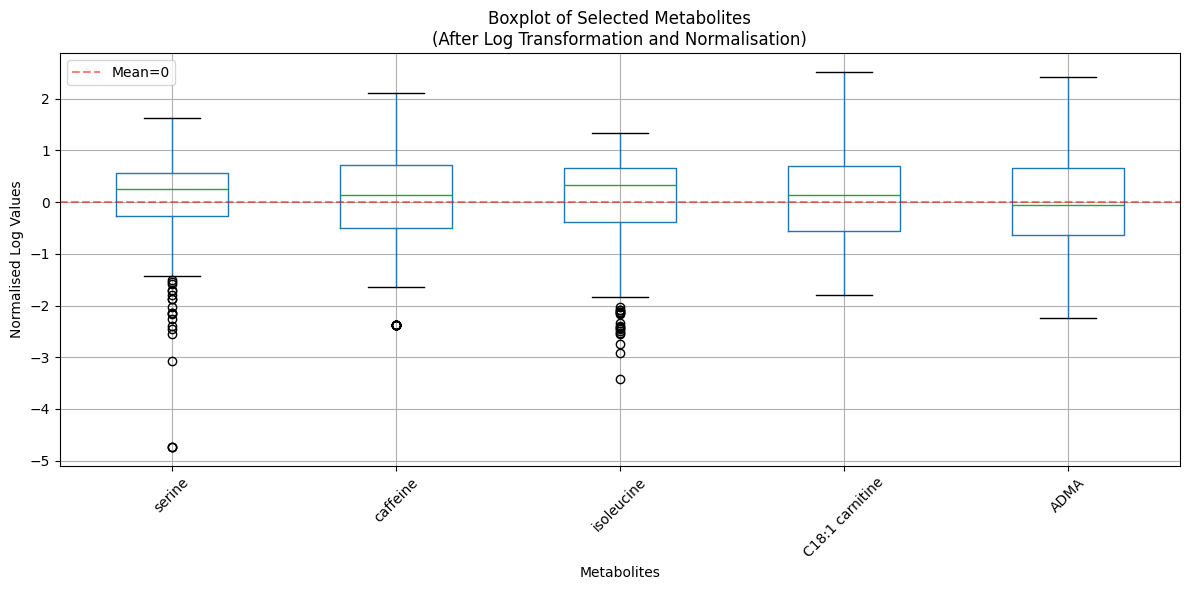

Boxplot shows outliers as circles beyond the whiskers
Features with most outliers: serine(20), caffeine(19), isoleucine(18)
Features with no outliers: C18:1 carnitine, ADMA


In [19]:
# Visualise outliers using boxplots
# We select features with most and least outliers for comparison

features_to_plot = ['serine', 'caffeine', 'isoleucine',
                    'C18:1 carnitine', 'ADMA']

fig, ax = plt.subplots(figsize=(12, 6))

# Boxplot of normalised log transformed data
X_scaled[features_to_plot].boxplot(ax=ax)
ax.set_title('Boxplot of Selected Metabolites\n(After Log Transformation and Normalisation)')
ax.set_xlabel('Metabolites')
ax.set_ylabel('Normalised Log Values')
ax.tick_params(axis='x', rotation=45)

# Add a horizontal line at y=0 (the mean)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Mean=0')
ax.legend()

plt.tight_layout()
plt.show()

print("Boxplot shows outliers as circles beyond the whiskers")
print("Features with most outliers: serine(20), caffeine(19), isoleucine(18)")
print("Features with no outliers: C18:1 carnitine, ADMA")

## Step 12: Train/Test Split with Stratification
We split data into 80% training and 20% testing.
Stratification ensures CD, UC and Control are
proportionally represented in both sets.

In [20]:
# Import train_test_split
from sklearn.model_selection import train_test_split

# Split data 80% train, 20% test
# stratify=y maintains class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,        # log transformed and normalised features
    y,               # diagnosis labels
    test_size=0.2,   # 20% for testing
    random_state=123, # reproducibility
    stratify=y        # maintain class proportions
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in testing set:")
print(y_test.value_counts())

Training set size: (176, 20)
Testing set size: (44, 20)

Class distribution in training set:
Factors
Diagnosis:CD         70
Diagnosis:UC         61
Diagnosis:Control    45
Name: count, dtype: int64

Class distribution in testing set:
Factors
Diagnosis:CD         18
Diagnosis:UC         15
Diagnosis:Control    11
Name: count, dtype: int64


## Step 13: Random Forest Classifier with Class Weighting
Random Forest builds 100 decision trees and takes majority vote.
class_weight='balanced' automatically gives more importance
to minority classes (Control=56) during training.
This addresses our class imbalance problem.

In [21]:
# Import Random Forest and evaluation tools
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create Random Forest with class weighting
# n_estimators=100 means 100 decision trees vote together
# class_weight='balanced' automatically calculates weights
# so minority classes get more attention during training
# random_state=123 ensures reproducibility

rf_model = RandomForestClassifier(
    n_estimators=100,        # 100 trees in the forest
    class_weight='balanced', # handle class imbalance
    random_state=123         # reproducibility
)

# Train the model on training data
# fit() makes the model learn patterns from 176 patients
rf_model.fit(X_train, y_train)

# Predict on test set - 44 patients model has never seen
y_pred_rf = rf_model.predict(X_test)

# Print classification report
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report:
                   precision    recall  f1-score   support

     Diagnosis:CD       0.72      0.72      0.72        18
Diagnosis:Control       0.57      0.73      0.64        11
     Diagnosis:UC       0.58      0.47      0.52        15

         accuracy                           0.64        44
        macro avg       0.63      0.64      0.63        44
     weighted avg       0.64      0.64      0.63        44



## Step 12.5: Feature Selection using Random Forest Importance
We use Random Forest feature importance to identify
the most relevant metabolites before final modelling.
A preliminary Random Forest is trained to rank features.
We keep only features with importance above the mean importance.
This removes noise and improves model performance.

In [22]:
# Step 1 - Train a preliminary Random Forest just for feature selection
# This is NOT our final model - just used to rank feature importance

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train preliminary Random Forest
rf_selector = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=123
)

rf_selector.fit(X_train, y_train)

# Get feature importances
# Feature importance tells us how much each metabolite
# contributed to the model's decisions
importances = rf_selector.feature_importances_
feature_names = X_train.columns

# Create a dataframe of feature importances
import pandas as pd
importance_df = pd.DataFrame({
    'Metabolite': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("Feature importances ranked:")
print(importance_df)
print("\nMean importance:", round(importances.mean(), 4))

Feature importances ranked:
                              Metabolite  Importance
19                 N-Acetylglutamic acid    0.130466
5                        C18:1 carnitine    0.073076
1                           pyridoxamine    0.071038
13                linoleoyl ethanolamide    0.064716
7                                 Harman    0.062064
11                       1-methylguanine    0.050682
3                              carnitine    0.048076
6                                   ADMA    0.045084
12                    N-acetylspermidine    0.044604
10                      3-methylxanthine    0.043490
9   5-acetylamino-6-amino-3-methyluracil    0.042334
17                 C16:1 LPC plasmalogen    0.041513
18                              caffeine    0.039909
4                             isoleucine    0.039273
0                        proline betaine    0.037972
15                        kynurenic acid    0.036259
14                     3-methylhistidine    0.035729
2                 

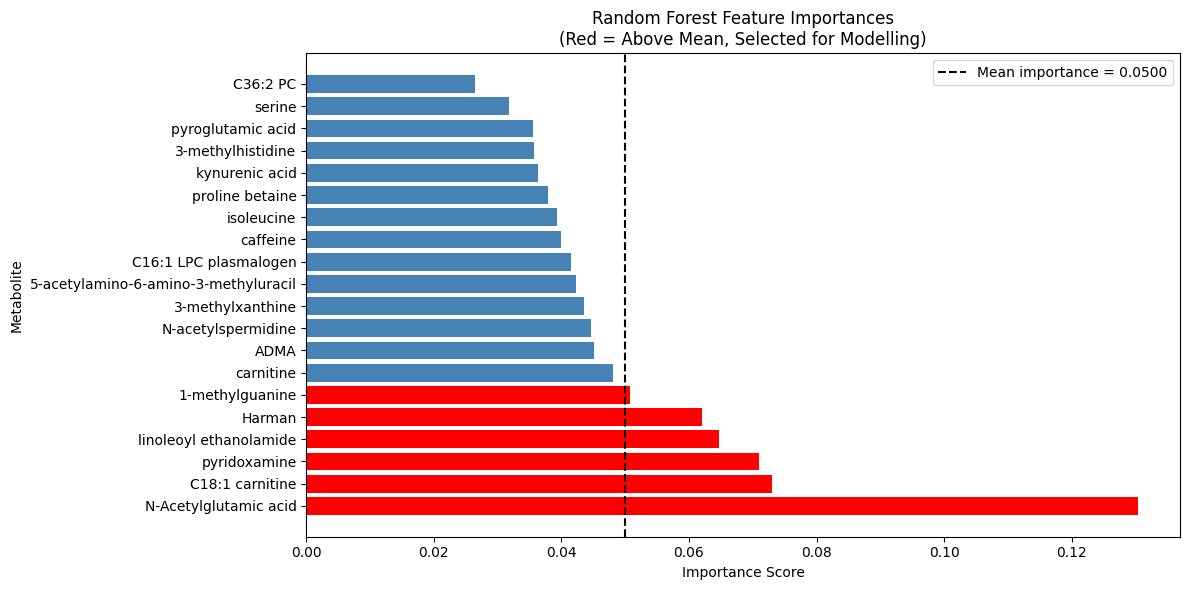

Selected features above mean importance:
1. N-Acetylglutamic acid
2. C18:1 carnitine
3. pyridoxamine
4. linoleoyl ethanolamide
5. Harman
6. 1-methylguanine

Number of features selected: 6


In [23]:
# Visualise feature importances using a bar chart
# This helps us clearly see which metabolites matter most

fig, ax = plt.subplots(figsize=(12, 6))

# Plot horizontal bar chart sorted by importance
colors = ['red' if imp >= importances.mean()
          else 'steelblue' for imp in importance_df['Importance']]

ax.barh(importance_df['Metabolite'],
        importance_df['Importance'],
        color=colors)

# Add vertical line at mean importance
ax.axvline(x=importances.mean(),
           color='black',
           linestyle='--',
           label=f'Mean importance = {importances.mean():.4f}')

ax.set_title('Random Forest Feature Importances\n(Red = Above Mean, Selected for Modelling)')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Metabolite')
ax.legend()

plt.tight_layout()
plt.show()

# Select features above mean importance
selected_features = importance_df[
    importance_df['Importance'] >= importances.mean()
]['Metabolite'].tolist()

print("Selected features above mean importance:")
for i, f in enumerate(selected_features):
    print(f"{i+1}. {f}")
print(f"\nNumber of features selected: {len(selected_features)}")

## Step 14: XGBoost Classifier
XGBoost uses boosting - each tree learns from errors of previous tree.
We compare XGBoost results with Random Forest to find the better model.
Both models run on all 20 features for fair comparison.

In [24]:
# Import XGBoost and required tools
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost requires numeric labels not text
# LabelEncoder converts CD/UC/Control to numbers 0/1/2
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Print label encoding so we know which number = which disease
print("Label encoding:")
for i, label in enumerate(le.classes_):
    print(f"{i} = {label}")

# Calculate sample weights to handle class imbalance
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

# Create XGBoost model
# n_estimators=100 = 100 boosting rounds
# learning_rate=0.1 = how much each tree corrects errors
# max_depth=3 = limits complexity to prevent overfitting
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=123,
    eval_metric='mlogloss'
)

# Train XGBoost with sample weights for class imbalance
xgb_model.fit(X_train, y_train_encoded,
              sample_weight=sample_weights)

# Predict and convert back to original labels
y_pred_xgb_encoded = xgb_model.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

# Print results
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Label encoding:
0 = Diagnosis:CD
1 = Diagnosis:Control
2 = Diagnosis:UC

XGBoost Classification Report:
                   precision    recall  f1-score   support

     Diagnosis:CD       0.80      0.67      0.73        18
Diagnosis:Control       0.82      0.82      0.82        11
     Diagnosis:UC       0.61      0.73      0.67        15

         accuracy                           0.73        44
        macro avg       0.74      0.74      0.74        44
     weighted avg       0.74      0.73      0.73        44



## Step 15: Model Comparison
We compare Random Forest and XGBoost results visually.
This helps us clearly see which model performs better
for each disease group and overall.

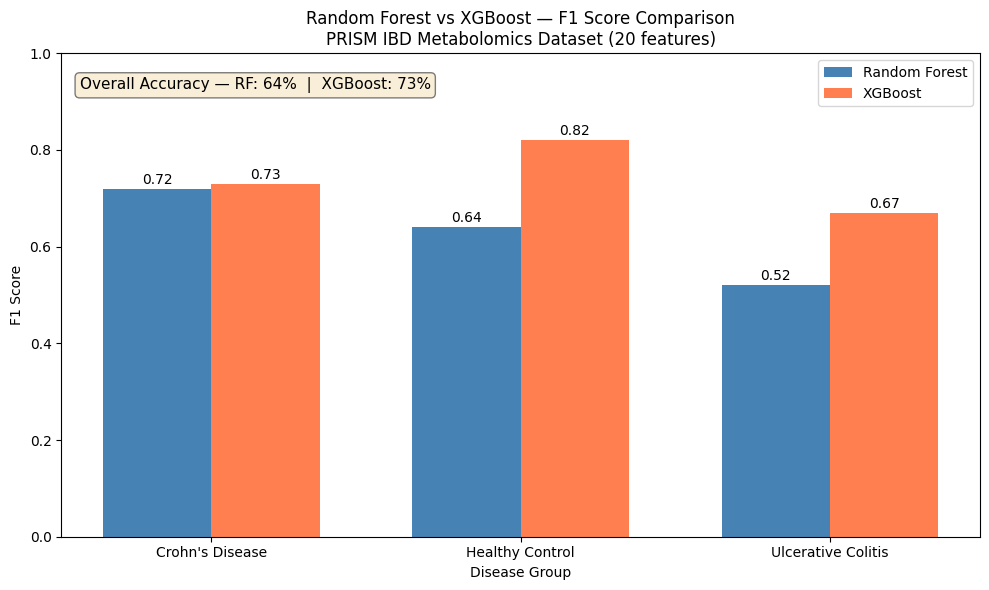

Key finding: XGBoost outperforms Random Forest on all disease groups!
Overall accuracy improvement: 64% → 73%


In [25]:
# We create a visual comparison of Random Forest vs XGBoost
# Side by side bar chart showing F1 scores for each disease group

# F1 scores from both models
classes = ['Diagnosis:CD', 'Diagnosis:Control', 'Diagnosis:UC']

rf_f1 = [0.72, 0.64, 0.52]      # Random Forest F1 scores
xgb_f1 = [0.73, 0.82, 0.67]     # XGBoost F1 scores

x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot bars for both models
bars1 = ax.bar(x - width/2, rf_f1, width,
               label='Random Forest', color='steelblue')
bars2 = ax.bar(x + width/2, xgb_f1, width,
               label='XGBoost', color='coral')

# Add value labels on top of each bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{bar.get_height():.2f}',
            ha='center', fontsize=10)

# Add overall accuracy as text
ax.text(0.02, 0.95,
        f'Overall Accuracy — RF: 64%  |  XGBoost: 73%',
        transform=ax.transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax.set_xlabel('Disease Group')
ax.set_ylabel('F1 Score')
ax.set_title('Random Forest vs XGBoost — F1 Score Comparison\nPRISM IBD Metabolomics Dataset (20 features)')
ax.set_xticks(x)
ax.set_xticklabels(['Crohn\'s Disease', 'Healthy Control', 'Ulcerative Colitis'])
ax.legend()
ax.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

print("Key finding: XGBoost outperforms Random Forest on all disease groups!")
print(f"Overall accuracy improvement: 64% → 73%")

## Step 16: XGBoost Feature Importance
XGBoost also ranks feature importance like Random Forest.
We compare which metabolites both models agree are important.
Agreement between two models strengthens biological conclusions.

XGBoost Feature Importances:
                              Metabolite  Importance
19                 N-Acetylglutamic acid    0.129460
5                        C18:1 carnitine    0.108990
17                 C16:1 LPC plasmalogen    0.075375
1                           pyridoxamine    0.063775
13                linoleoyl ethanolamide    0.061120
18                              caffeine    0.056283
10                      3-methylxanthine    0.055262
11                       1-methylguanine    0.047257
7                                 Harman    0.042469
2                      pyroglutamic acid    0.041571
9   5-acetylamino-6-amino-3-methyluracil    0.040691
12                    N-acetylspermidine    0.040668
0                        proline betaine    0.036072
8                               C36:2 PC    0.033660
15                        kynurenic acid    0.032569
3                              carnitine    0.032283
16                                serine    0.028782
6                

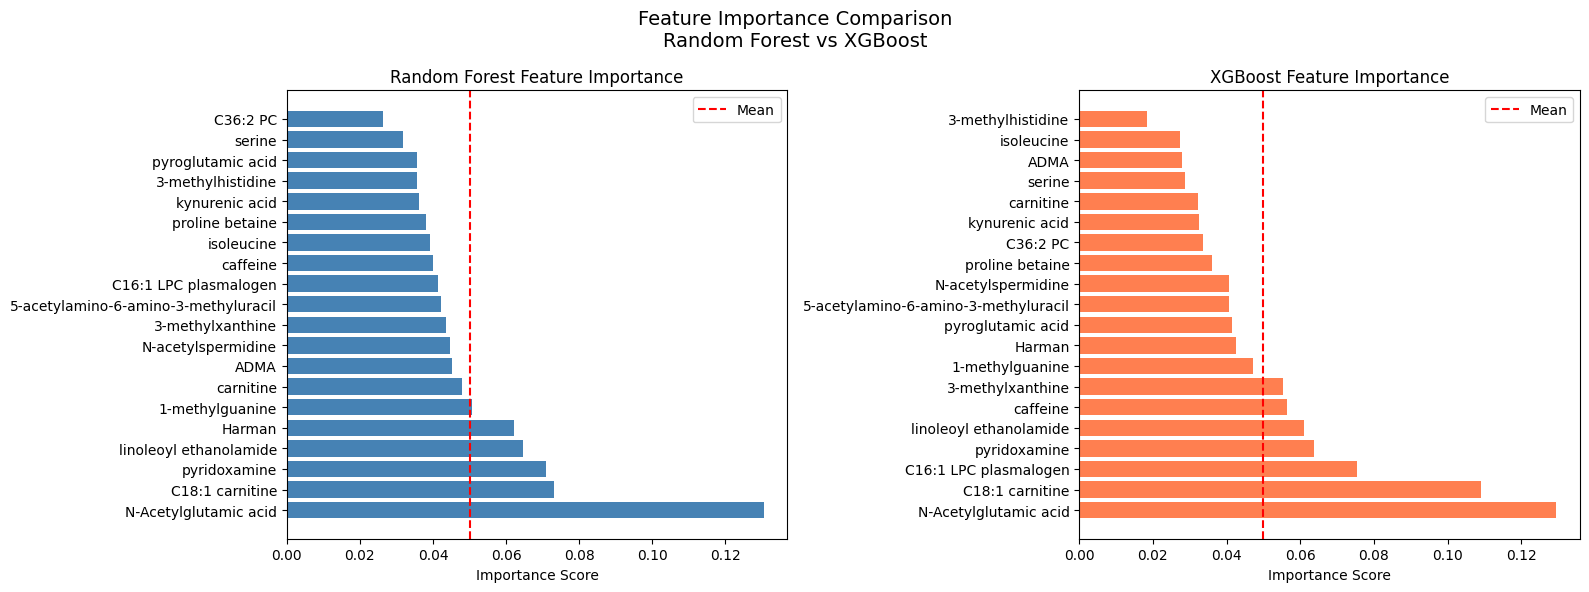

In [26]:
# XGBoost feature importance
# XGBoost measures importance differently from Random Forest
# It counts how many times each feature was used to split data
# across all 100 boosting rounds

xgb_importances = xgb_model.feature_importances_

# Create importance dataframe
xgb_importance_df = pd.DataFrame({
    'Metabolite': X_train.columns,
    'Importance': xgb_importances
}).sort_values('Importance', ascending=False)

print("XGBoost Feature Importances:")
print(xgb_importance_df)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest importance
axes[0].barh(importance_df['Metabolite'],
             importance_df['Importance'],
             color='steelblue')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(x=importances.mean(),
                color='red', linestyle='--',
                label='Mean')
axes[0].legend()

# XGBoost importance
axes[1].barh(xgb_importance_df['Metabolite'],
             xgb_importance_df['Importance'],
             color='coral')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')
axes[1].axvline(x=xgb_importances.mean(),
                color='red', linestyle='--',
                label='Mean')
axes[1].legend()

plt.suptitle('Feature Importance Comparison\nRandom Forest vs XGBoost',
             fontsize=14)
plt.tight_layout()
plt.show()